# Monetary Reputation Model - Main Simulation

In [1]:
using Plots 
using DelimitedFiles

includet("model_solver.jl") 

## Model Parameters

In [2]:
params = ModelParameters(;
    gammas = (;  π_target_1 = 0.02,  # inflation if only type 1 
                π_target_2 = 0.03),  # inflation if only type 2 
    epsilon = 0.02, delta = 0.02, sigma = 5.0, beta = 0.99, alpha = 1.0,
    h = (mu) -> 1/2 * mu^2, inv_hprime = (x) -> x,
    distribution = TruncatedExponentials(; max = 0.5, points = 2000, meanA = 0.04, meanB = 0.01),
    rho_points = 500
);

# Use 'distribution = TruncatedNormals(; max = 0.5, points = 2000, meanA = 0.05, meanB = 0.01, sigmaA = 0.015, sigmaB = 0.015)' for alternative distribution parameterization. 

ModelParameters{Float64, var"#104#105", var"#ModelParameters##8#ModelParameters##9", var"#106#107"}(Distribution{Float64}([0.0, 0.0002501250625312656, 0.0005002501250625312, 0.0007503751875937969, 0.0010005002501250625, 0.0012506253126563281, 0.0015007503751875938, 0.0017508754377188595, 0.002001000500250125, 0.0022511255627813906  …  0.4977488744372186, 0.49799899949974985, 0.49824912456228115, 0.4984992496248124, 0.49874937468734365, 0.49899949974987495, 0.4992496248124062, 0.49949974987493745, 0.49974987493746875, 0.5], [0.0062336395407496656, 0.006194781422734235, 0.006156165531322673, 0.006117790356567238, 0.006079654397932619, 0.006041756164237271, 0.006004094173595099, 0.00596666695335752, 0.005929473040055877, 0.005892510979344215  …  2.4575476493494146e-8, 2.4422282398836116e-8, 2.4270043257407346e-8, 2.411875311639568e-8, 2.3968406060096488e-8, 2.38189962096814e-8, 2.3670517722968388e-8, 2.3522964794193358e-8, 2.337633165378311e-8, 2.323061256812977e-8], [0.02470228536803198,

# Running the Simulations

## Solving the games

**Solving the Full Game**

In [3]:
@time optimal_policies, dynamics, _ = solve_dynamic_game(
    params, verbose = true, max_iters = 1_000, tol = 1e-5, printevery = 50);

Iterating value and policy functions ...
    Iteration 50, diff = 0.0010273960991353803
    Iteration 100, diff = 0.00029791584032223817
    Iteration 150, diff = 0.0001018754792003751
    Iteration 200, diff = 4.804909605282681e-5
    Iteration 250, diff = 2.5024804477968843e-5
    Iteration 300, diff = 1.5140957076109629e-5
... done.
 20.373377 seconds (6.53 M allocations: 507.297 MiB, 0.75% gc time, 49.75% compilation time)


**Solving the Reference Game: Period 0**

In [4]:

reference = solve_reference_game(params);

**Solving the Reference Game: Period 1**

This corresponds to the model with fixed types:

In [5]:
fixed_types_game = solve_reference_period1(params);

In [6]:

# Checking that the implied expected inflation rates for fixed types match targets
@assert expected_one_plus_mua(params, fixed_types_game.mu1) ≈ 1.02
@assert expected_one_plus_mua(params, fixed_types_game.mu2) ≈ 1.03

**Ergodic Distributions**

In [7]:
ergodic = ergodic_distribution(dynamics.T)  # unconditional
ergodic1 = ergodic_distribution(dynamics.T1)  # type 1
ergodic2 = ergodic_distribution(dynamics.T2);  # type 2

# ergodic inflation 
ergodic_pi = ergodic_inflation(params, optimal_policies);

**Reputation paths**

In [8]:
# Reputation paths from mean (0.5)
paths1 = simulate_rho_paths(0.5, dynamics, params; periods = 100)
rho_path, rho_path_1, rho_path_2 = paths1;

# Obtaining the values used in the paper

In [9]:
# Values of gamma1 and gamma2 that achieve the targets 
println("Values of gamma1 and gamma2 that achieve the inflation targets:")
println("  gamma1 = $(params.inflation_costs.gamma1), gamma2 = $(params.inflation_costs.gamma2)")
# Model with fixed types (Reference game in period 1)
println()
println("Equilibrium outcomes in the Reference Game with Fixed Types:")
println("  P1 = $(fixed_types_game.P1), Elogcminusalphac = $(Elogcminusalphac(fixed_types_game.mu1, params))")
println("  P2 = $(fixed_types_game.P2), Elogcminusalphac = $(Elogcminusalphac(fixed_types_game.mu2, params))")
println()
println("Average inflation in the ergodic distribution: $(100 * ergodic_pi.average)")
println()
println("Values of rho after 100 periods conditional on type: $((rho_path_1[end], rho_path_2[end]))")

Values of gamma1 and gamma2 that achieve the inflation targets:
  gamma1 = 0.017073194732354285, gamma2 = 0.009233406982354848

Equilibrium outcomes in the Reference Game with Fixed Types:
  P1 = 1.3126998076027632, Elogcminusalphac = -1.0296742680602498
  P2 = 1.3379951905911123, Elogcminusalphac = -1.0320057542978929

Average inflation in the ergodic distribution: 2.122751616424494

Values of rho after 100 periods conditional on type: (0.6212370205441, 0.3818927371177545)


## Plots used in the paper

In [10]:
rho_grid = get_rho_grid(params);

### Price Level P

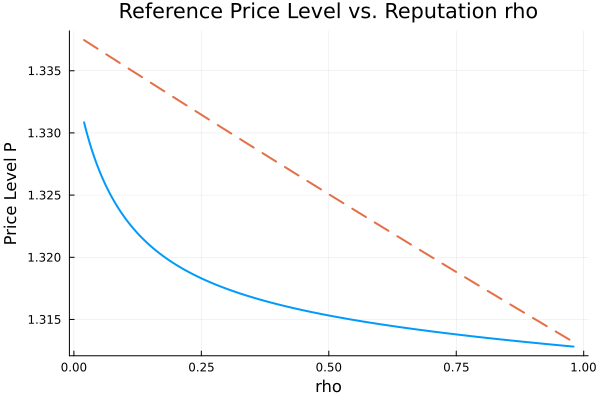

In [11]:
f1 = plot(rho_grid, optimal_policies.P, xlabel="rho", ylabel="Price Level P", linewidth = 2, label = "")
plot!(f1, rho_grid, reference.P0, xlabel="rho", ylabel="Price Level P", title="Reference Price Level vs. Reputation rho", linewidth = 2, label = "", linestyle = :dash)

### Optimal mu Policies

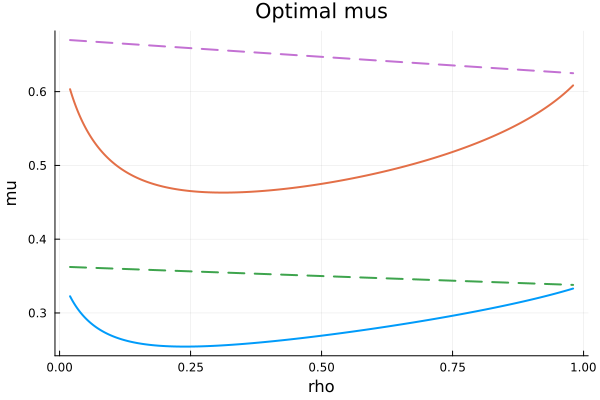

In [12]:
f2 = plot(rho_grid, optimal_policies.mu1_pol, xlabel="rho", ylabel="mu", title="Optimal mus", linewidth = 2, label = "" )
plot!(f2, rho_grid, optimal_policies.mu2_pol, linewidth = 2, label = "")
plot!(f2, rho_grid, reference.mu0_1, label = "", linestyle = :dash, linewidth = 2)
plot!(f2, rho_grid, reference.mu0_2, label = "", linestyle = :dash, linewidth = 2)

### Value Functions

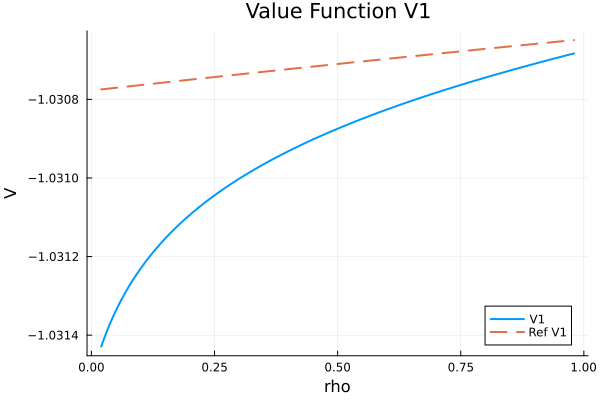

In [13]:
# V1
f3a = plot(rho_grid, optimal_policies.V1, xlabel="rho", ylabel="V", title="Value Function V1", linewidth = 2, label = "V1")
plot!(f3a, rho_grid, reference.V1, linewidth = 2, label = "Ref V1", linestyle = :dash)

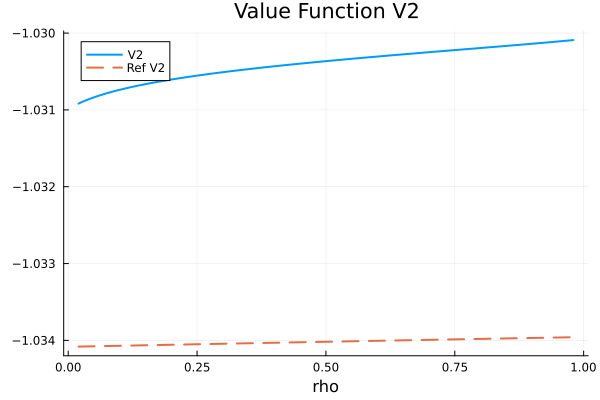

In [14]:
# V2
f3b = plot(rho_grid, optimal_policies.V2, xlabel="rho", title="Value Function V2", linewidth = 2, label = "V2")
plot!(f3b, rho_grid, reference.V2, linewidth = 2, label = "Ref V2", linestyle = :dash)

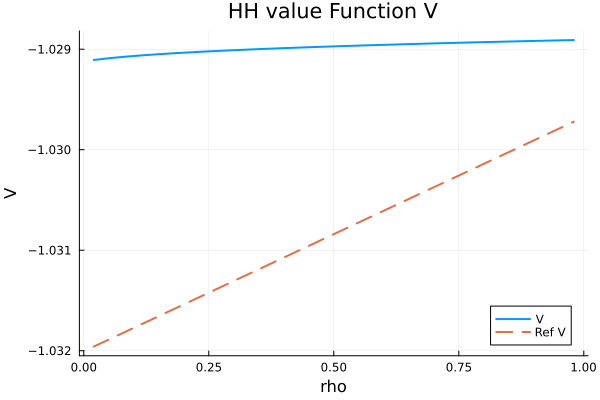

In [15]:
# V (Household value function)
f3c = plot(rho_grid, optimal_policies.V, xlabel="rho", ylabel="V", title="HH value Function V", linewidth = 2, label = "V")
plot!(f3c, rho_grid, reference.V, linewidth = 2, label = "Ref V", linestyle = :dash)

### Reputation Paths

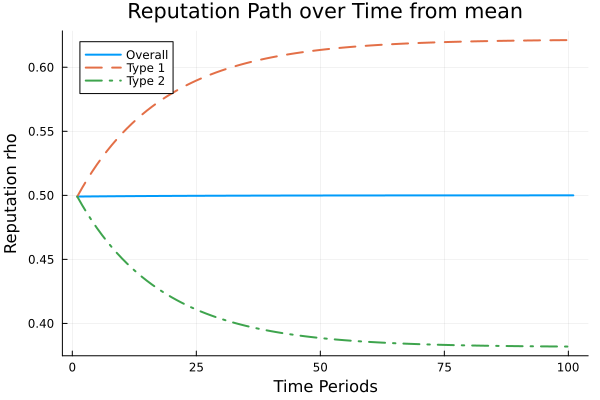

In [16]:
f4 = plot(rho_path, xlabel="Time Periods", ylabel="Reputation rho", title="Reputation Path over Time from mean", linewidth = 2, label = "Overall")
plot!(f4, rho_path_1, linewidth = 2, label = "Type 1", linestyle = :dash)
plot!(f4, rho_path_2, linewidth = 2, label = "Type 2", linestyle = :dashdot)

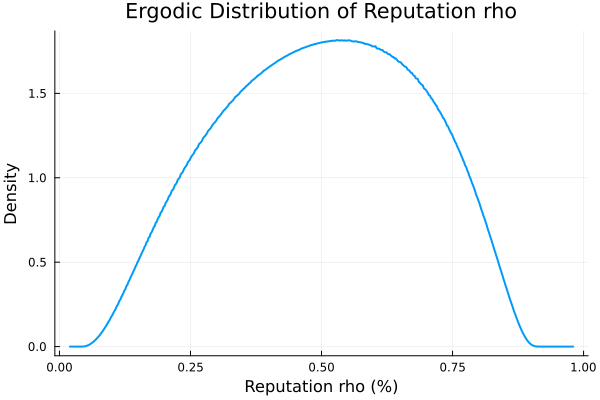

In [17]:
f5 = plot(rho_grid, ergodic ./ (rho_grid[2] - rho_grid[1]), xlabel = "Reputation rho (%)", ylabel = "Density", title = "Ergodic Distribution of Reputation rho", legend = false, lw = 2)

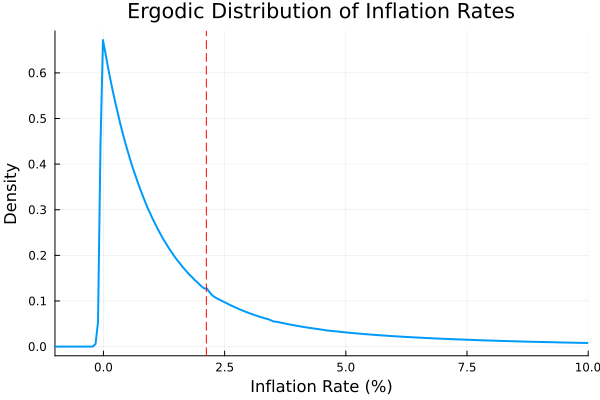

In [18]:
ergodic_pi_step = 100 * (ergodic_pi.grid[2] - ergodic_pi.grid[1])
f6 = plot(ergodic_pi.grid .* 100, ergodic_pi.density ./ ergodic_pi_step, xlabel = "Inflation Rate (%)", ylabel = "Density", title = "Ergodic Distribution of Inflation Rates", legend = false, xlims = (-1, 10), lw = 2)
vline!(f6, [ergodic_pi.average * 100], line = (:red, :dash), label = "Average Inflation Rate")

## Exporting Results

In [19]:
mkpath("results")

# Exporting data to CSV files for plotting in Tikz 

toexport = (
    get_rho_grid(params),
    optimal_policies.P,
    reference.P0,
    optimal_policies.mu1_pol,
    reference.mu0_1,
    optimal_policies.mu2_pol,
    reference.mu0_2,
    optimal_policies.V1,
    reference.V1,
    optimal_policies.V2,
    reference.V2,
    optimal_policies.V,
    reference.V
)

writedlm(joinpath("results", "rhoaxisplots.csv"), [ [a...]  for a in zip(toexport...)],  ',')

writedlm(joinpath("results", "ergodicinflation.csv"), [ [a...] for a in zip(ergodic_pi.grid .* 100, ergodic_pi.density ./ ergodic_pi_step)], ',')

writedlm(joinpath("results", "pathplots.csv"), [ [a...]  for a in zip(paths1...)],  ',')